# 01 | Dữ liệu, nhãn và tín hiệu

Inventory → nhãn và split → baseline lịch sử → beat detection → chất lượng PPG.

**Nguồn:** [HealthSense MachineLearning Lab](https://github.com/HealthSense-IUH/HealthSense-MachineLearning-Lab) ở commit chốt trong manifest. **Chỉ đọc artifact**, không fit lại model và không ghi đè freeze.

In [1]:
import sys
from pathlib import Path
import os
_candidates=[Path.cwd(), Path.cwd()/'notebooks'/'HealthSense_Defense_Evidence_Notebooks', Path.cwd()/'HealthSense_Defense_Evidence_Notebooks']
if os.getenv('HEALTHSENSE_NOTEBOOK_DIR'): _candidates.insert(0,Path(os.environ['HEALTHSENSE_NOTEBOOK_DIR']).expanduser())
for _p in _candidates:
    if (_p/'healthsense_evidence_utils.py').is_file(): sys.path.insert(0,str(_p.resolve())); break
from healthsense_evidence_utils import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print('REPO:',ROOT,'\nOUT:',OUT)
print('GIT:',git_info())

REPO: /home/phuc/Documents/HealthSense_rungtamnhi 
OUT: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z
GIT: {'head': '1b9d9094cddb6f7fbe95e1f31fd969f0c537e22e', 'status_porcelain': '?? ": update README with V5 V6 datasets and references\\""\n?? experiments/02_beat_detector/official_detector_results.csv\n?? experiments/02_beat_detector/official_detector_summary.csv\n?? experiments/02_beat_detector/run_official_detectors.m\n?? experiments/02_beat_detector/score_official_detectors.py\n?? experiments/02_beat_detector/test_msptdfast.m\n?? experiments/02_beat_detector/test_msptdfast_peaks.csv\n?? experiments/02_beat_detector/test_ppg.csv\n?? experiments/02_beat_detector/test_qppgfast.m\n?? experiments/02_beat_detector/test_qppgfast_peaks.csv\n?? experiments/06_external_validation/audit_liu_dataset.py\n?? experiments/06_external_validation/audit_liu_signal.py\n?? experiments/06_external_validation/deepbeat_duplicate_overlap_audit.py\n?

## 1. Danh mục bằng chứng và nguồn dữ liệu
Các con số được đọc lại từ các file `.csv` thực có trong GitHub/local. `prediction_generation_audit` là danh mục số cửa sổ sau làm sạch của DEV/TEST, không phải toàn bộ số người huấn luyện.

,dataset,split,rows_valid,subjects,AF_windows,nonAF_windows,temporal_quality
0,deepbeat,dev,4026,13,509,3517,verified_candidate
1,deepbeat,test_reused,1363,7,611,752,verified_candidate
2,pulsewatch,dev,17679,16,2320,15359,candidate_requires_audit
3,pulsewatch,test_reused,30158,16,3472,26686,candidate_requires_audit
4,liu,dev,997,7,53,944,verified_candidate
5,liu,test_reused,920,7,440,480,verified_candidate


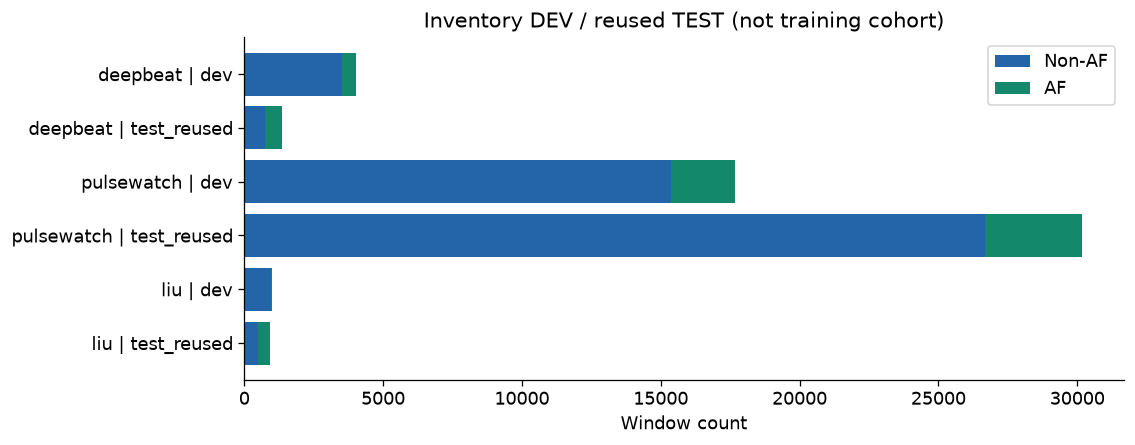

,key,dataset,split,exists,rows_input,rows_valid,subjects,AF_windows,nonAF_windows,session_key,order_key,temporal_quality
0,deepbeat_dev,deepbeat,dev,True,4026,4026,13,509,3517,source,timestamp,verified_candidate
1,deepbeat_test,deepbeat,test_reused,True,1363,1363,7,611,752,source,timestamp,verified_candidate
2,pulsewatch_dev,pulsewatch,dev,True,17679,17679,16,2320,15359,trial,segment,candidate_requires_audit
3,pulsewatch_test,pulsewatch,test_reused,True,30158,30158,16,3472,26686,trial,segment,candidate_requires_audit
4,liu_dev,liu,dev,True,997,997,7,53,944,NaN,idx_0,verified_candidate
5,liu_test,liu,test_reused,True,920,920,7,440,480,NaN,idx_0,verified_candidate


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z/01_prediction_inventory.csv')

In [2]:
A=EVIDENCE_PREFIX
inventory=csv(A+'prediction_generation_audit.csv')
display(inventory[['dataset','split','rows_valid','subjects','AF_windows','nonAF_windows','temporal_quality']])
long=inventory.melt(id_vars=['dataset','split'],value_vars=['AF_windows','nonAF_windows'],var_name='label',value_name='windows')
fig,ax=plt.subplots(figsize=(10,4)); labels=[]; pos=[]
for i,(_,r) in enumerate(inventory.iterrows()):
    labels.append(f"{r.dataset} | {r.split}")
    ax.barh(i,r.nonAF_windows,color=BLUE,label='Non-AF' if i==0 else None)
    ax.barh(i,r.AF_windows,left=r.nonAF_windows,color=GREEN,label='AF' if i==0 else None)
ax.set_yticks(range(len(labels)),labels);ax.invert_yaxis();ax.set_xlabel('Window count');ax.legend();ax.set_title('Inventory DEV / reused TEST (not training cohort)');figure(fig,'01_inventory_windows')
table(inventory,'01_prediction_inventory')

## 2. Kiểm soát trùng người giữa các split
Kết quả audit đã lưu, **không** thay thế việc rà soát bản manifest gốc hoặc mã group của stacking trainer. `n_overlap` phải bằng 0 trong từng dataset.

,dataset,split_a,split_b,n_overlap,overlap_subjects
0,deepbeat,train,dev,0,NaN
1,deepbeat,train,test,0,NaN
2,deepbeat,dev,test,0,NaN
3,pulsewatch,train,dev,0,NaN
4,pulsewatch,train,test,0,NaN
5,pulsewatch,dev,test,0,NaN
6,liu,train,dev,0,NaN
7,liu,train,test,0,NaN
8,liu,dev,test,0,NaN


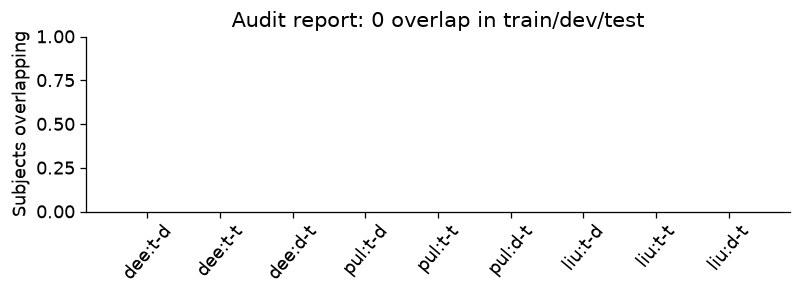

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z/02_split_overlap.png')

In [3]:
overlap=csv(A+'subject_split_overlap_audit.csv')
assert (overlap.n_overlap==0).all(), 'Có subject overlap được báo cáo, cần điều tra.'
display(overlap)
fig,ax=plt.subplots(figsize=(7,2.7));ax.bar(range(len(overlap)),overlap.n_overlap,color=GREEN);ax.set_xticks(range(len(overlap)),[f"{r.dataset[:3]}:{r.split_a[0]}-{r.split_b[0]}" for _,r in overlap.iterrows()],rotation=50);ax.set_ylabel('Subjects overlapping');ax.set_ylim(0,1);ax.set_title('Audit report: 0 overlap in train/dev/test');figure(fig,'02_split_overlap')

## 3. Baseline lịch sử, chỉ dùng để chứng minh tiến trình
Đây là phép thử MIMIC PERform AF ở thời kỳ baseline, **không phải kết quả frozen stacked model**. Giữ tách window-level với subject-level.

,Model,Level,Accuracy,Recall (Sensitivity),Specificity,Precision,F1-Score,ROC-AUC,FN,FP,TP,TN
0,Logistic Regression,window,0.922760,0.982159,0.852225,0.887545,0.932458,0.870674,40,279,2202,1609
1,Logistic Regression,subject,0.942857,1.000000,0.875000,0.904762,0.950000,0.875000,0,2,19,14
2,Random Forest,window,0.921308,0.974576,0.858051,0.890746,0.930777,0.939800,57,268,2185,1620
3,Random Forest,subject,0.942857,1.000000,0.875000,0.904762,0.950000,0.930921,0,2,19,14
4,XGBoost,window,0.918160,0.962979,0.864936,0.894366,0.927405,0.912932,83,255,2159,1633
5,XGBoost,subject,0.942857,1.000000,0.875000,0.904762,0.950000,0.901316,0,2,19,14


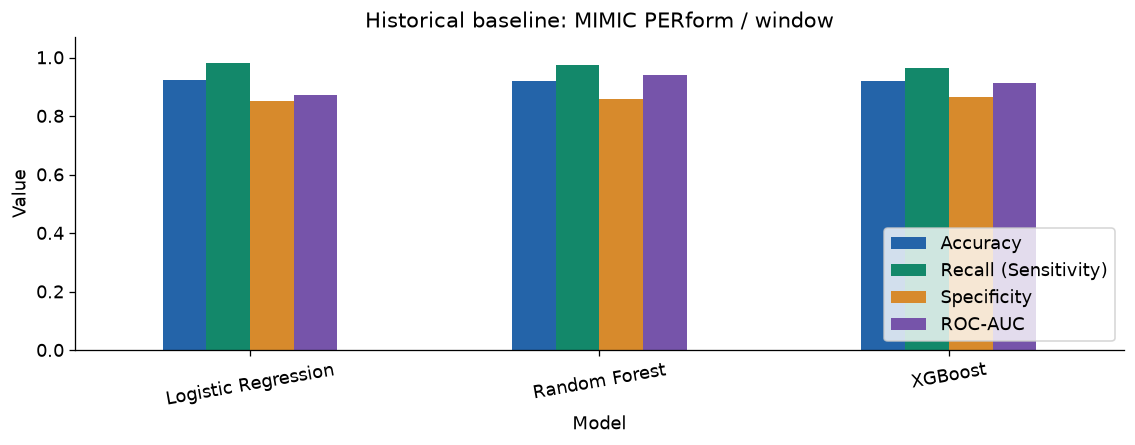

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z/03_historical_baseline.png')

In [4]:
base=csv('experiments/00_baseline_reproduction/artifacts/benchmark_results_v4.csv')
display(base)
w=base[base.Level.eq('window')].set_index('Model')
metrics=['Accuracy','Recall (Sensitivity)','Specificity','ROC-AUC']
fig,ax=plt.subplots(figsize=(10,4));w[metrics].plot(kind='bar',ax=ax,color=[BLUE,GREEN,ORANGE,PURPLE]);ax.set_ylim(0,1.07);ax.set_ylabel('Value');ax.set_title('Historical baseline: MIMIC PERform / window');ax.legend(loc='lower right');ax.tick_params(axis='x',rotation=10);figure(fig,'03_historical_baseline')

## 4. Label audit AFIB / AFL
Đồ thị biểu diễn **thay đổi metric ở một protocol lịch sử**, không suy diễn là gain của mô hình stacking. Kiểm tra cặp nhãn trước khi diễn giải.

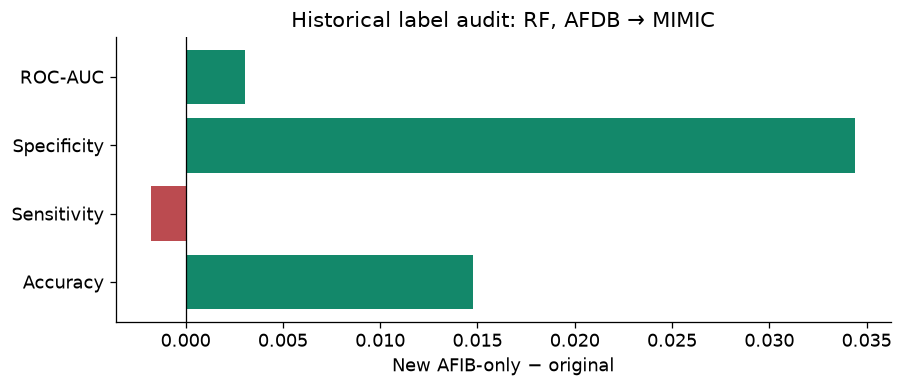

,Direction,Model,Accuracy_delta,Specificity_delta,ROC-AUC_delta
0,MIMIC -> AFDB,Logistic Regression,0.005276,0.000000,0.003554
1,MIMIC -> AFDB,Random Forest,0.005240,0.000000,0.002125
2,MIMIC -> AFDB,XGBoost,0.005109,0.000000,0.003408
3,AFDB -> MIMIC,Logistic Regression,-0.001937,-0.006356,0.004634
4,AFDB -> MIMIC,Random Forest,0.014770,0.034428,0.003031
5,AFDB -> MIMIC,XGBoost,0.006780,0.016949,0.002921


In [5]:
label=csv('experiments/01_label_audit/cross_dataset_comparison.csv')
x=label[(label.Direction=='AFDB -> MIMIC')&(label.Model=='Random Forest')].iloc[0]
cols=['Accuracy_delta','Recall (Sensitivity)_delta','Specificity_delta','ROC-AUC_delta']
vals=[x[c] for c in cols]; fig,ax=plt.subplots(figsize=(8,3.5)); ax.barh(['Accuracy','Sensitivity','Specificity','ROC-AUC'],vals,color=[GREEN if t>=0 else RED for t in vals]);ax.axvline(0,color='black',lw=.8);ax.set_xlabel('New AFIB-only − original');ax.set_title('Historical label audit: RF, AFDB → MIMIC');figure(fig,'04_label_audit_delta');display(label[['Direction','Model','Accuracy_delta','Specificity_delta','ROC-AUC_delta']])

## 5. Beat detector benchmark
Median per subject: AF và non-AF riêng. Không trình bày F1 của beat detector như F1 của AF classifier.

,method,label,n_subjects,median_f1,median_sensitivity,median_ppv,median_hr_mae,median_ptt_ms
0,current_scipy,AF,19,0.854839,0.832961,0.884580,4.70,272.0
1,current_scipy,Non-AF,16,0.990786,0.989920,0.991022,1.10,620.0
2,neurokit_elgendi,AF,19,0.837176,0.802074,0.882294,4.65,264.0
3,neurokit_elgendi,Non-AF,16,0.992053,0.989622,0.996125,1.00,628.0


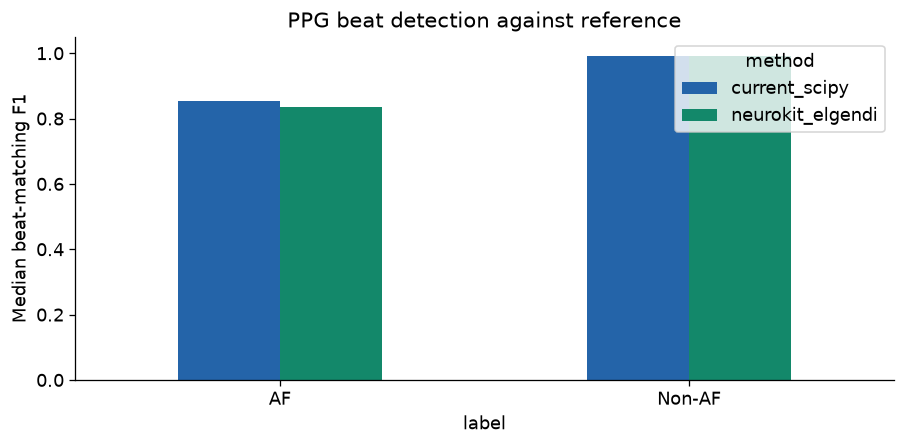

PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z/05_beat_detection.png')

In [6]:
beat=csv('experiments/02_beat_detector/beat_detector_summary.csv')
display(beat)
fig,ax=plt.subplots(figsize=(8,4)); b=beat.pivot(index='label',columns='method',values='median_f1').reindex(['AF','Non-AF']);b.plot(kind='bar',ax=ax,color=[BLUE,GREEN]);ax.set_ylim(0,1.05);ax.set_ylabel('Median beat-matching F1');ax.set_title('PPG beat detection against reference');ax.tick_params(axis='x',rotation=0);figure(fig,'05_beat_detection')

## 6. PPG-only SQI: ROC được tái tính từ prediction CSV thực
Đây là phân loại **window quality**, không phải AF detection. Không tự động bật hard-gating khi SQI chưa đủ tốt. Các tỷ lệ 24,5% leakage ở ngưỡng 0,30 được ghi trong `experiments/03_sqi/README.md`.

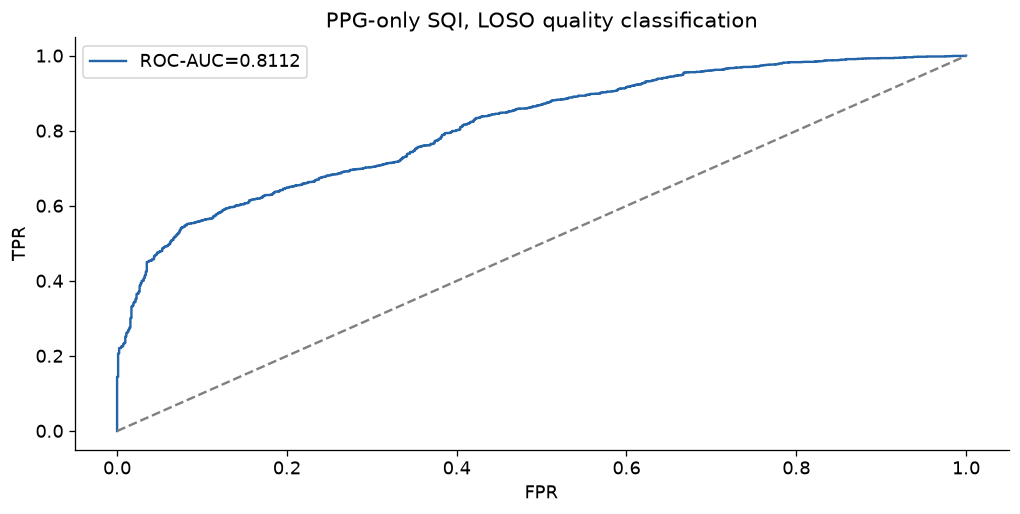

,label,windows,mean_quality_score,good_fraction
0,AF,2242,0.658088,0.740856
1,Non-AF,1888,0.818677,0.868644


Evidence statement from repository README: SQI AUROC 0.8112; AF poor-quality window leakage 0.245 at threshold 0.30. Do not use as hard gate.


In [7]:
sqi=csv('experiments/03_sqi/sqi_loso_predictions.csv',required=False)
if sqi is not None:
    assert {'quality_good','quality_score'}.issubset(sqi.columns)
    from sklearn.metrics import roc_curve,roc_auc_score
    y=sqi.quality_good.astype(int);score=sqi.quality_score.astype(float)
    val=roc_auc_score(y,score);fpr,tpr,thr=roc_curve(y,score)
    fig,ax=plt.subplots();ax.plot(fpr,tpr,color=BLUE,label=f'ROC-AUC={val:.4f}');ax.plot([0,1],[0,1],ls='--',color='gray');ax.set(xlabel='FPR',ylabel='TPR',title='PPG-only SQI, LOSO quality classification');ax.legend();figure(fig,'06_sqi_roc')
    summary=sqi.groupby('label').agg(windows=('quality_good','size'),mean_quality_score=('quality_score','mean'),good_fraction=('quality_good','mean')).reset_index();table(summary,'06_sqi_label_inventory')
else: print('Skip: prediction-level SQI file not present.')
print('Evidence statement from repository README: SQI AUROC 0.8112; AF poor-quality window leakage 0.245 at threshold 0.30. Do not use as hard gate.')

## 7. Đăng ký nguồn
Notebook chỉ chứng minh những artifact vừa đọc. Cần raw PPG/ECG có quyền truy cập để lặp lại beat detection từ tín hiệu; không có raw waveform thì không vẽ waveform giả.

In [8]:
manifest('01_Data_Label_and_Signal_Audit', ['Historical baseline is distinct from V6C freeze','SQI quality target is not AF label','No retraining or raw-signal reconstruction performed'])

Nguồn và checksum: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z/01_Data_Label_and_Signal_Audit_input_manifest.json
Biểu đồ: 6 | thư mục: /home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z


PosixPath('/home/phuc/Documents/HealthSense_rungtamnhi/outputs/healthsense_defense_evidence/20260929T060103_185463Z/01_Data_Label_and_Signal_Audit_input_manifest.json')